# Steam-methane reforming
$$
\newcommand{\dd}{\mathrm{d}}
\newcommand{\Pressure}{p}
\newcommand{\PartialPressure}[1]{p_{#1}}
\newcommand{\MolarFlowRate}[1]{F_{#1}}
%
\newcommand{\ReactionRate}[1]{r_{#1}}
\newcommand{\RateFormation}[1]{R_{#1}}
\newcommand{\RateConst}[1]{k_{#1}}
\newcommand{\EquilibriumConst}[1]{K_{#1}}
$$

In [2]:
import os
from datetime import datetime
from pathlib import Path
from enum import Enum
import sqlite3

import numpy as np
import pandas as pd

from IPython.display import display, Image, Latex

from phdtools import DATA_DIR, RESULTS_DIR
from phdtools.data.constants import GAS_CONST_SI
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    auto_create_path,
    write_metadata,
    request_free_id,
)

overwrite = False
FILE_DATE = os.getenv("FILE_DATE", "260407")
TODAY = datetime.today().strftime("%y%m%d")

if overwrite:
    FILE_DATE = TODAY

## Table of contents

- [Xu and Froment (1989)](#Xu-and-Froment-1989)
    - [Equilibrium constant(s)](#Equilibrium-constant(s))
    - [Rate coefficients and adsorption coefficients](#Rate-coefficients-and-adsorption-coefficients)
    - [Reaction rates](#Reaction-rates)
    - [Plug flow reactor model](#Plug-flow-reactor-model)
    - [Verification with Xu and Froment Fig. 2](#Verification-with-Xu-and-Froment-Fig.-2)
    - [Space-time conversion plot with non-equilibrium region](#Space-time-conversion-plot-with-non-equilibrium-region)
    - [Product distribution](#Product-distribution)
- [Equilibrium conversion from CEP](#Equilibrium-conversion-from-CEP)
- [References](#References)

## Xu and Froment (1989)
[back](#Table-of-contents)

$$\ce{CH4 + H2O <=> CO + 3H2}\tag{I}\label{eq:SR}$$

$$\ce{CO + H2O <=> CO2 + H2}\tag{II}\label{eq:WGS}$$

$$\ce{CH4 + 2 H2O <=> CO2 + 4H2}\tag{III}\label{eq:DSR}$$

Rate equations as given by [Xu and Froment (1989)](#References)
$$
\begin{aligned}
    \ReactionRate{\mathrm{I}} = \frac{\RateConst{\mathrm{I}}}{\PartialPressure{\ce{H2}}^{2.5}} 
        \left( \PartialPressure{\ce{CH4}}\PartialPressure{\ce{H2O}} - \frac{\PartialPressure{\ce{H2}}^3\PartialPressure{\ce{CO}}}{\EquilibriumConst{\mathrm{I}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
    %
    \ReactionRate{\mathrm{II}} = \frac{\RateConst{\mathrm{II}}}{\PartialPressure{\ce{H2}}} 
        \left( \PartialPressure{\ce{CO}}\PartialPressure{\ce{H2O}} - \frac{\PartialPressure{\ce{H2}}\PartialPressure{\ce{CO2}}}{\EquilibriumConst{\mathrm{II}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
    %
    \ReactionRate{\mathrm{III}} = \frac{\RateConst{\mathrm{III}}}{\PartialPressure{\ce{H2}}^{3.5}} 
        \left( \PartialPressure{\ce{CH4}}\PartialPressure{\ce{H2O}}^2 - \frac{\PartialPressure{\ce{H2}}^4\PartialPressure{\ce{CO2}}}{\EquilibriumConst{\mathrm{III}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
\end{aligned}
\tag{1}
\label{eq:rate-equations}
$$
From the stoichiometry of Eqs. \eqref{eq:SR} to \eqref{eq:DSR} it follows that 
$$
\begin{aligned}
    \RateFormation{\ce{CH4}} &= -\ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{III}} \\
    \RateFormation{\ce{CO}} &= \ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{II}} \\
    \RateFormation{\ce{CO2}} &= \ReactionRate{\mathrm{II}} + \ReactionRate{\mathrm{III}} \\
    \RateFormation{\ce{H2O}} &= -\ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{II}} - 2 \ReactionRate{\mathrm{III}} \\
    \RateFormation{\ce{H2}} &= 3 \ReactionRate{\mathrm{I}} + \ReactionRate{\mathrm{II}} + 4 \ReactionRate{\mathrm{III}}
\end{aligned}
\tag{2}
\label{eq:stoichiometry}
$$

### Equilibrium constant(s)
[back](#Table-of-contents)

Equilibrium constants can be computed the standard Gibbs free reaction enthalpy $\Delta_\mathrm{r} G_i^\circ$, which is thermodynamically exact:
$$
\Delta_\mathrm{r} G_i^\circ = - R T \ln K_i, \quad i = \mathrm{I},\mathrm{II},\mathrm{III} \implies K_i = \exp{\left(-\Delta_\mathrm{r} G_i^\circ/RT\right)}, \quad i = \mathrm{I},\mathrm{II},\mathrm{III}
$$
Where 
$$
\Delta_\mathrm{r} G_i^\circ = \Delta_\mathrm{r} H_i^\circ - T \, \Delta_\mathrm{r} S_i^\circ 
    = \sum_j \nu_{ij} \Delta_\mathrm{f} G_j^\circ 
    = \sum_j \nu_{ij} \left( \Delta_\mathrm{f} H_j^\circ - T S_j^\circ \right)
$$
see [Atkins (2023)](#References)

#### Equilibrium constants from tabulated data

In [3]:
from phdtools.models.xu_froment_1989 import logEquilibriumConst

logEquilibriumConst.head()

,WGS,SMR,DSR
T(K),,,
600.0,3.345376,-14.514468,-11.169092
700.0,2.245313,-8.236423,-5.991110
800.0,1.442216,-3.474969,-2.032753
900.0,0.835091,0.260456,1.095548
1000.0,0.363343,3.268642,3.631985


By definition $K_1 \, K_2 = K_3$

In [4]:
assert all(
    np.isclose(
        logEquilibriumConst["SMR"]
        + logEquilibriumConst["WGS"]
        - logEquilibriumConst["DSR"],
        0,
    )
)

#### Van't Hoff model for temperature dependence

$$
K_i = K_i(T_r) \exp \left[ \frac{\Delta_\mathrm{r} H_i}{R} \left(\frac{1}{T} - \frac{1}{T_r}\right)  \right], \quad i = \mathrm{I},\mathrm{II},\mathrm{III}
$$

In [5]:
from phdtools.models.xu_froment_1989 import Reaction, ModelParameters

params = ModelParameters.init()

In [6]:
display(
    Latex(
        rf"At reference temperature $T_r = {params.refTemperatureEquilibriumSI}\,\mathrm{{K}}$ the reaction enthalpies $\Delta H_i(T_r)$ are:"
    )
)

for i, label in enumerate(["SMR", "WGS", "DSR"]):
    display(
        Latex(
            rf"$\Delta H_\mathrm{{{label}}}(T_r) = {params.enthalpyReactionSI[Reaction[label].value]/1000:.2f} \, \mathrm{{kJ/mol}}$, $K_\mathrm{{{label}}}(T_r) = {params.equilibriumConstRef[i]:.2f}$"
        )
    )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

**Compare this to the shift reactor:**

In [7]:
from phdtools.models.mendes_2010 import ModelParameters as ShiftParameters

shift_params = ShiftParameters.init(model="LH1")

In [8]:
display(
    Latex(
        rf"At reference temperature $T_r = {shift_params.refTemperatureEquilibriumSI}\,\mathrm{{K}}$ the reaction enthalpies $\Delta H_i(T_r)$ are:"
    )
)

display(
    Latex(
        rf"$\Delta H_\mathrm{{WGS}}(T_r) = {shift_params.enthalpyReactionSI/1000:.2f} \, \mathrm{{kJ/mol}}$, $K_\mathrm{{WGS}}(T_r) = {shift_params.equilibriumConstRef:.2f}$"
    )
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [18]:
params = ModelParameters.init()
params

ModelParameters(rateConstantRefSI=array([5.11666667e-05, 2.09944444e+00, 6.09166667e-06]), activationEnergySI=array([240100.,  67130., 243900.]), equilibriumConstRef=array([26.27562736,  1.43812874, 37.78773494]), enthalpyReactionSI=array([225723., -34783., 190940.]), adsorptionCoefRef=array([1.791e-01, 4.091e+01,       nan, 2.960e-02, 4.152e-01,       nan,
             nan,       nan]), enthalpyAdsorptionSI=array([-38280., -70650.,     nan, -82900.,  88680.,     nan,     nan,
           nan]), refTemperatureEquilibriumSI=array([1000., 1000., 1000.]), refTemperatureAdsorptionSI=array([823., 648.,  nan, 648., 823.,  nan,  nan,  nan]), refTemperatureRateSI=array([648, 648, 648]))

In [24]:
data_id = DataID(DataType.TABLE, Chapter.METHODS, 3)


@auto_create_path
def save_equilibrium_const_model_ref_values(path):
    fname = path / f"{TODAY}_equilibrium_const_model_ref_values.csv"

    params = ModelParameters.init()
    shift_params = ShiftParameters.init(model="LH1")

    df = pd.DataFrame(
        data={
            "Reaction":[r.name for r in Reaction],
            "Tr(K)":params.refTemperatureEquilibriumSI,
            "dH[Tr](kJ/mol)":params.enthalpyReactionSI / 1000,
            "K[Tr]":params.equilibriumConstRef,
        },
    )
    df = df.set_index(["Reaction", "Tr(K)"])

    df.loc[("WGS", 500.0), "dH[Tr](kJ/mol)"] = shift_params.enthalpyReactionSI / 1000
    df.loc[("WGS", 500.0), "K[Tr]"] = shift_params.equilibriumConstRef

    df = df.iloc[[0, 3, 1, 2]]

    description = (
        "Values for for the equilibrium constant K and standard reaction enthalpy dH of\n"
        "the steam methane reforming (SMR), water-gas shift (WGS), and direct steam\n"
        "reforming (DSR) calculated using tabulated data from Allison (2013)\n"
        "for the Gibbs free energy of formation reactions at different reference temperatures Tr.\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n"
    )

    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        df.to_csv(f)


save_equilibrium_const_model_ref_values(
    data_id,
    doc=r"Values for for the equilibrium constant and standard reaction enthalpy at the different reference temperatures; with the data taken from \textcite{Allison.2013a}",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/UKLDWj' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [25]:
!ls {DataID(DataType.TABLE, Chapter.METHODS, 3).get_path(fail_exists=False)}

260407_equilibrium_const_model_ref_values.csv


In [26]:
from phdtools.models.xu_froment_1989 import equilibriumConstModel

data_id = DataID(DataType.FIGURE, Chapter.METHODS, 12)

temperatureRange = np.linspace(600, 1600)
equilibriumConstModelValues = equilibriumConstModel(temperatureRange, params)[
    :, [Reaction["SMR"].value, Reaction["WGS"].value, Reaction["DSR"].value]
]
logEquilibriumConstModelValues = np.log(equilibriumConstModelValues)


@auto_create_path
def save_equilibrium_const_model_values(path):

    description = (
        "Equilibrium constants of the steam methane reforming (SMR), \n"
        "water-gas shift (WGS), and direct steam reforming (DSR) reactions calculated\n"
        "using tabulated data from Allison (2013) for the Gibbs free energy of formation.\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n"
    )

    fname = path / f"{TODAY}_log_equilibrium_const_nist.csv"
    with open(fname, "w") as f:
        write_metadata(f, description=description)
        logEquilibriumConst.to_csv(f)

    description = (
        "Van't Hoff model for the equilibrium constants of the steam methane reforming (SMR), \n"
        "water-gas shift (WGS), and direct steam reforming (DSR) reactions.\n"
        "Based on tabulated data from Allison (2013) for the Gibbs free energy of formation.\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n"
    )

    fname = path / f"{TODAY}_log_equilibrium_const_model.csv"
    with open(fname, "w") as f:
        write_metadata(f, description=description)
        np.savetxt(
            f,
            np.c_[temperatureRange, logEquilibriumConstModelValues],
            delimiter=",",
            header="T(K),log10K1,log10K2,log10K3",
        )


save_equilibrium_const_model_values(
    data_id,
    doc=r"Arrhenius plot for the equilibrium constants of the steam methane reforming, water-gas shift, and direct steam reforming reactions based on \textcite{Allison.2013a}.",
    overwrite=overwrite,
)

In [27]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 12).get_path(fail_exists=False)}

260407_log_equilibrium_const_model.csv 260407_log_equilibrium_const_nist.csv


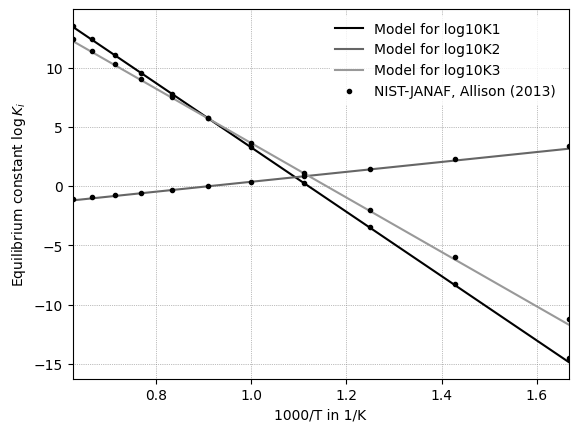

In [28]:
from phdtools.plots.smr import plot_eq_constant_temperature_dependence

fig = plot_eq_constant_temperature_dependence(
    file_model=DataID(DataType.FIGURE, Chapter.METHODS, 12).get_path(fail_exists=False)
    / f"{FILE_DATE}_log_equilibrium_const_nist.csv",
    file_tabulated=DataID(DataType.FIGURE, Chapter.METHODS, 12).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_log_equilibrium_const_model.csv",
)

### Rate coefficients and adsorption coefficients
[back](#Table-of-contents)

In [29]:
from phdtools.models.xu_froment_1989 import (
    rateConstModel,
    adsorptionCoefModel,
    Compound,
    Reaction,
)

In [30]:
temperatureRange = np.linspace(1000 / 1.8, 1000 / 1.2)

k = 1e-3 * rateConstModel(temperatureRange, params) * 3600  # in kJ/(kg cat * h)
K = adsorptionCoefModel(temperatureRange, params)

values = np.c_[
    temperatureRange,
    np.log10(k[:, Reaction["SMR"].value]),
    np.log10(k[:, Reaction["WGS"].value]),
    np.log10(k[:, Reaction["DSR"].value]),
    np.log10(K[:, Compound["C1O1(g)"].value]),
    np.log10(K[:, Compound["H2(ref)"].value]),
    np.log10(K[:, Compound["C1H4(g)"].value]),
    np.log10(K[:, Compound["H2O1(g)"].value]),
]

header = ",".join(
    [
        "T(K)",
        "log10 k1",
        "log10 k2",
        "log10 k3",
        "log10 KCO",
        "log10 KH2",
        "log10 KCH4",
        "log10 KH2O",
    ]
)

data_id = DataID(DataType.FIGURE, Chapter.METHODS, 11)


@auto_create_path
def save_xu_froment_parameters_model(path):

    description = (
        "Temperature dependence of the rate and adsorption parameters (k and K, \n"
        "respectively) modelled after and recreating Xu and Froment (1989, fig. 9).\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
        '    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
        "    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
    )

    fname = path / f"{TODAY}_xu_froment_temperature_dependence_parameters.csv"
    with open(fname, "w") as f:
        write_metadata(f, description=description)
        np.savetxt(f, values, delimiter=",", header=header)


save_xu_froment_parameters_model(
    data_id,
    doc=r"Temperature dependence of the rate and adsorption parameters modelled after and recreating \textcite[fig. 9]{Xu.1989a}",
    overwrite=overwrite,
)

In [31]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 11).get_path(fail_exists=False)}

260407_xu_froment_temperature_dependence_parameters.csv


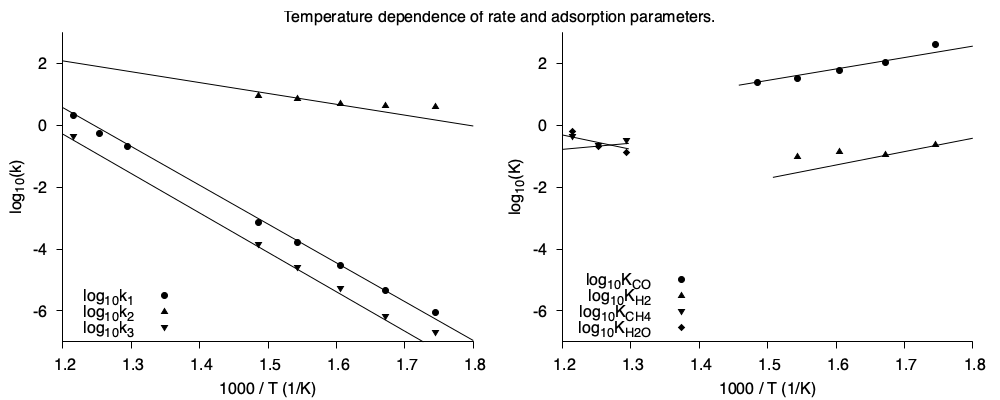

In [32]:
tmp = (
    DataID(DataType.FIGURE, Chapter.METHODS, 11).get_path(fail_exists=False)
    / f"{FILE_DATE}_xu_froment_temperature_dependence_parameters.csv"
)
!gnuplot -e "filename='{tmp}'; call 'plot_240829_xu_froment_fig9.gnu'" 2> /dev/null
del tmp
Image("plots/plot_240829_xu_froment_fig9.png")

### Reaction rates
[back](#Table-of-contents)

In [33]:
from phdtools.models.xu_froment_1989 import reactionRateModel

Recall \eqref{eq:rate-equations} were the reaction rates proposed by [Xu and Froment (1989)](#References) are given by
$$
\begin{aligned}
    \ReactionRate{\mathrm{I}} = \frac{\RateConst{\mathrm{I}}}{\PartialPressure{\ce{H2}}^{2.5}} 
        \left( \PartialPressure{\ce{CH4}}\PartialPressure{\ce{H2O}} - \frac{\PartialPressure{\ce{H2}}^3\PartialPressure{\ce{CO}}}{\EquilibriumConst{\mathrm{I}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
    %
    \ReactionRate{\mathrm{II}} = \frac{\RateConst{\mathrm{II}}}{\PartialPressure{\ce{H2}}} 
        \left( \PartialPressure{\ce{CO}}\PartialPressure{\ce{H2O}} - \frac{\PartialPressure{\ce{H2}}\PartialPressure{\ce{CO2}}}{\EquilibriumConst{\mathrm{II}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
    %
    \ReactionRate{\mathrm{III}} = \frac{\RateConst{\mathrm{III}}}{\PartialPressure{\ce{H2}}^{3.5}} 
        \left( \PartialPressure{\ce{CH4}}\PartialPressure{\ce{H2O}}^2 - \frac{\PartialPressure{\ce{H2}}^4\PartialPressure{\ce{CO2}}}{\EquilibriumConst{\mathrm{III}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
\end{aligned}
$$

In [34]:
partialPressureBar = np.ones(
    len(Compound), dtype=np.float64
)  # p_j: partial pressure of component j, bar
r1, _, r3 = reactionRateModel(partialPressureBar, 1000, params)

print(
    f"r_CH4(1 bar, 1000 K) = {(-r1-r3):.2f} mol/(kg(cat) * s) = {(-r1-r3)*3.6:.2f} mol/(g(cat) * h)"
)

r_CH4(1 bar, 1000 K) = -11.82 mol/(kg(cat) * s) = -42.56 mol/(g(cat) * h)


### Plug flow reactor model
[back](#Table-of-contents)

The material for a plug flow reactor with solid catalyst particles is
$$
\dd F_j = R_j \mathrm{d} W,\quad j = \ce{CH4}, \ce{CO}, \ce{CO2}, \ce{H2}, \ce{H2O} \tag{3}
\label{eq:material-balance}
$$
where the rate equations \eqref{eq:rate-equations} are from [Xu and Froment (1989)](#References)
$$
\begin{aligned}
    \ReactionRate{\mathrm{I}} = \frac{\RateConst{\mathrm{I}}}{\PartialPressure{\ce{H2}}^{2.5}} 
        \left( \PartialPressure{\ce{CH4}}\PartialPressure{\ce{H2O}} - \frac{\PartialPressure{\ce{H2}}^3\PartialPressure{\ce{CO}}}{\EquilibriumConst{\mathrm{I}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
    %
    \ReactionRate{\mathrm{II}} = \frac{\RateConst{\mathrm{II}}}{\PartialPressure{\ce{H2}}} 
        \left( \PartialPressure{\ce{CO}}\PartialPressure{\ce{H2O}} - \frac{\PartialPressure{\ce{H2}}\PartialPressure{\ce{CO2}}}{\EquilibriumConst{\mathrm{II}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
    %
    \ReactionRate{\mathrm{III}} = \frac{\RateConst{\mathrm{III}}}{\PartialPressure{\ce{H2}}^{3.5}} 
        \left( \PartialPressure{\ce{CH4}}\PartialPressure{\ce{H2O}}^2 - \frac{\PartialPressure{\ce{H2}}^4\PartialPressure{\ce{CO2}}}{\EquilibriumConst{\mathrm{III}}} \right) \left/ (\mathrm{DEN})^2 \right. \\
\end{aligned}
$$
and the rates of formation $\RateFormation{j}$ are given by eq. \eqref{eq:stoichiometry} as
$$
\begin{aligned}
    \RateFormation{\ce{CH4}} &= -\ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{III}} \\
    R_{\ce{CO}} &= \ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{II}} \\
    R_{\ce{CO2}} &= \ReactionRate{\mathrm{II}} + \ReactionRate{\mathrm{III}} \\
    R_{\ce{H2O}} &= -\ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{II}} - 2 \ReactionRate{\mathrm{III}} \\
    R_{\ce{H2}} &= 3 \ReactionRate{\mathrm{I}} + \ReactionRate{\mathrm{II}} + 4 \ReactionRate{\mathrm{III}}
\end{aligned}
$$
and
$$
\PartialPressure{i} = \Pressure\frac{\MolarFlowRate{i}}{\sum_j \MolarFlowRate{j}} \tag{4}
\label{eq:partial-pressure}
$$

#### Verification with Xu and Froment Fig. 2
[back](#Table-of-contents)

In [35]:
from phdtools.models.xu_froment_1989 import initialValueProblemSpaceTime

$$
\begin{aligned}
    \frac{\dd}{\dd W} 
    \begin{bmatrix}
        F_\ce{CH4}\\F_\ce{CO2}
    \end{bmatrix}
     = 
    \begin{bmatrix}
        -\ReactionRate{\mathrm{I}} - \ReactionRate{\mathrm{III}}\\
        \ReactionRate{\mathrm{II}}+\ReactionRate{\mathrm{III}}
    \end{bmatrix}
\end{aligned}
$$

In [36]:
!ls {DATA_DIR / "xu-froment-1989"}

240805_table_4_raw_xu_froment.csv
240805_table_5_xu_froment.csv
241007_figure_2_experiment_xu_froment.csv
250716_table_4_values_xu_froment.csv


In [37]:
fname = DATA_DIR / "xu-froment-1989" / "241007_figure_2_experiment_xu_froment.csv"
df = pd.read_csv(
    fname, sep=",", comment="#", names=["T(K)", "W/F_CH4,0", "X_CH4"], index_col=0
)
df.head()

,"W/F_CH4,0",X_CH4
T(K),,
773,0.131388,0.010149
773,0.151920,0.010961
773,0.203245,0.014411
773,0.254573,0.017050
773,0.305907,0.017253


In [38]:
import scipy
from scipy.integrate import solve_ivp

pressureBar = 10

molarFlowRateIn = 0 * np.ones(len(Compound), dtype=np.float64)
molarFlowRateIn[Compound["C1H4(g)"].value] = 1
molarFlowRateIn[Compound["H2O1(g)"].value] = (
    3 * molarFlowRateIn[Compound["C1H4(g)"].value]
)
molarFlowRateIn[Compound["H2(ref)"].value] = (
    1.25 * molarFlowRateIn[Compound["C1H4(g)"].value]
)

spaceTimeSI = np.linspace(0, 0.5 * 3.6, 250)  # in kg(cat) s / mol
temperatureRange = np.array([773, 798, 823, 848])

conversion = np.zeros((len(temperatureRange), len(spaceTimeSI)))
conversion[:] = np.nan

for num, temperatureKelvin in enumerate(temperatureRange):
    sol = solve_ivp(
        fun=initialValueProblemSpaceTime,
        t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
        y0=np.array([0, 0]),
        method="RK45",
        t_eval=spaceTimeSI,
        dense_output=False,
        events=None,
        vectorized=True,
        args=(molarFlowRateIn, temperatureKelvin, pressureBar, params),
    )

    conversion[num] = sol.y[0]

In [39]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 13)

description = (
    "Space time W/F_CH4,0 vs. conversion X_CH4, recreating Xu and Froment (1989, fig. 2).\n"
    f"Solved using the RKF45 implementation scipy.integrate.solve_ivp (scipy {scipy.__version__});\n"
    f"Equilibrium constants, see {DataID(DataType.FIGURE, Chapter.METHODS, 12).to_sqid()}\n"
    "Method: RK45\n"
    "Parameters: \n"
    f"  p = {pressureBar} bar; F_CH4,0 = {molarFlowRateIn[Compound['C1H4(g)'].value]} mol/s;\n"
    f"  F_H2O,0 = {molarFlowRateIn[Compound['H2O1(g)'].value]} mol/s; \n"
    f"  F_H2,0 = {molarFlowRateIn[Compound['H2(ref)'].value]} mol/s\n"
    "\n"
    "References:\n"
    "-----------\n"
    'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
    '    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
    "    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
    'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
    '    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
    "    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
)


@auto_create_path
def save_figure_2_model_xu_froment(path):
    fname = path / f"{TODAY}_figure_2_model_xu_froment.csv"

    with open(fname, "w") as f:
        write_metadata(f, description)
        f.write("# W/F_CH4,0(g(cat)*h/mol),0,X_CH4,T(K)\n")
        for num, temp in enumerate(np.array([773, 798, 823, 848])):
            np.savetxt(
                f,
                np.c_[
                    spaceTimeSI / 3.6,
                    conversion[num],
                    temp * np.ones(spaceTimeSI.shape),
                ],
                fmt=",".join(["%.18e", "%.18e", "%d"]),
                # header=",".join(["W/F_CH4,0","X_CH4","T(K)"]),
                comments="#",
            )
            f.write("\n")


save_figure_2_model_xu_froment(
    data_id,
    doc=r"Space time vs. conversion plot for steam reforming over \ce{Ni/MgAl2O4} (isothermal plug flow reactor); recreating \textcite[fig. 2]{Xu.1989a}",
    overwrite=overwrite,
)

In [40]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 13).get_path(fail_exists=False)}

260407_figure_2_model_xu_froment.csv


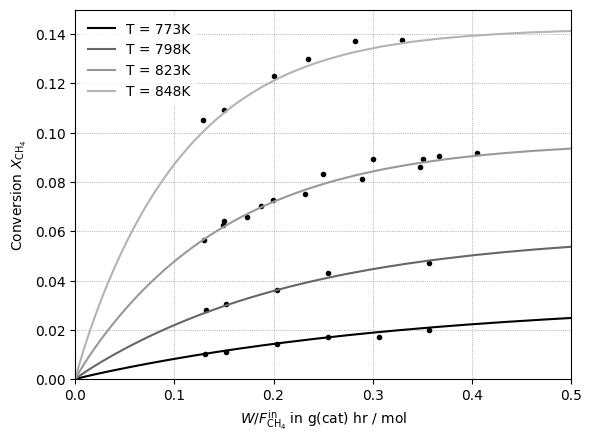

In [41]:
from phdtools.plots.smr import figure_two_xu_froment

fig = figure_two_xu_froment(
    file_experiment=DATA_DIR
    / "xu-froment-1989"
    / "241007_figure_2_experiment_xu_froment.csv",
    file_model=DataID(DataType.FIGURE, Chapter.METHODS, 13).get_path(fail_exists=False)
    / f"{FILE_DATE}_figure_2_model_xu_froment.csv",
)

#### Space-time conversion plot with non-equilibrium region
[back](#Table-of-contents)

In [42]:
from phdtools.models.xu_froment_1989 import stoichiometryReformer, inEquilibrium

temperatureRange = np.arange(750, 1400, 10)
eqSpaceTime = np.zeros(len(temperatureRange))
eqConversion = np.zeros(len(temperatureRange))
eqConversion[:] = np.nan

spaceTimeSI = np.linspace(0, 2 * 3.6, 1000)
conversion = np.zeros((len(temperatureRange), len(spaceTimeSI)))
conversion[:] = np.nan

for num, temperatureKelvin in enumerate(temperatureRange):
    sol = solve_ivp(
        fun=initialValueProblemSpaceTime,
        t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
        y0=np.array([0, 0]),
        method="RK45",
        t_eval=spaceTimeSI,
        dense_output=False,
        events=None,
        vectorized=True,
        args=(molarFlowRateIn, temperatureKelvin, pressureBar, params),
    )

    conversion[num] = sol.y[0]
    molarFlowRateOut = stoichiometryReformer(molarFlowRateIn, sol.y)
    idx = np.argwhere(
        inEquilibrium(pressureBar, temperatureKelvin, molarFlowRateOut, params)
    )

    if not idx.size == 0:
        idx = idx[0]
        eqSpaceTime[num] = sol.t[idx][0]
        eqConversion[num] = sol.y[0, idx][0]

/Users/marvinmeck/test/phd-tools-dev/phdtools/models/xu_froment_1989.py:436: RuntimeWarning: invalid value encountered in divide
  Q[Reaction["WGS"].value] = (


In [43]:
# from phdtools.rdm import request_free_id
# request_free_id(DataType.FIGURE, Chapter.UNUSED)
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 8)


@auto_create_path
def save_equilibrium_space_time(path):

    description = (
        "Space time W/F_CH4,0 vs. conversion X_CH4, see Xu and Froment (1989).\n"
        f"Solved using scipy.integrate.solve_ivp (scipy {scipy.__version__});\n"
        f"Equilibrium constants, see {DataID(DataType.FIGURE, Chapter.METHODS, 12).to_sqid()}\n"
        "Method: RK45\n"
        "Parameters: \n"
        f"  p = {pressureBar} bar; F_CH4,0 = {molarFlowRateIn[Compound['C1H4(g)'].value]} mol/s;\n"
        f"  F_H2O,0 = {molarFlowRateIn[Compound['H2O1(g)'].value]} mol/s; \n"
        f"  F_H2,0 = {molarFlowRateIn[Compound['H2(ref)'].value]} mol/s\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
        '    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
        "    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
        'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
        '    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
        "    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
    )

    fname = path / f"{TODAY}_conversion_space_time.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        np.savetxt(
            f,
            np.c_[spaceTimeSI / 3.6, conversion.T],
            delimiter=",",
            header="spaceTime(g(cat h)/mol),"
            + ",".join(
                f"{temperatureKelvin:.2f}" for temperatureKelvin in temperatureRange
            ),
            comments="",
        )

    description = (
        "Equilibrium conversion Xeq at different temperatures.\n"
        "determined by evaluating the reaction quotient and comparing it with\n"
        f"the equilibrium constants (see {DataID(DataType.FIGURE, Chapter.METHODS, 12).to_sqid()})\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
        '    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
        "    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
    )

    fname = path / f"{TODAY}_equilibrium_space_time.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        np.savetxt(
            f,
            np.c_[eqSpaceTime / 3.6, eqConversion],
            delimiter=",",
            header="W/F_CH4,0,eq(g(cat h)/mol),Xeq",
        )


save_equilibrium_space_time(
    data_id,
    doc=r"Space time vs. conversion plot for steam reforming over \ce{Ni/MgAl2O4} (isothermal plug flow reactor) with equilibrium conversion; see \textcite[fig. 2]{Xu.1989a}",
    overwrite=overwrite,
)

In [44]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 8).get_path(fail_exists=False)}

260407_conversion_space_time.csv  260407_equilibrium_space_time.csv


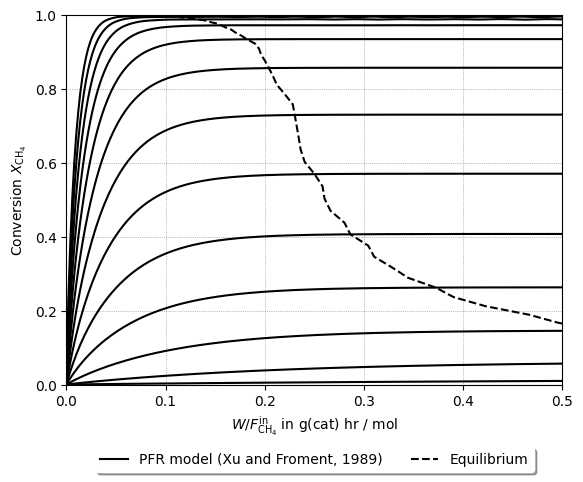

In [45]:
from phdtools.plots.smr import plot_equilibrium_space_time

fig = plot_equilibrium_space_time(
    fname_conversion=DataID(DataType.FIGURE, Chapter.UNUSED, 8).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_conversion_space_time.csv",
    fname_equilibrium=DataID(DataType.FIGURE, Chapter.UNUSED, 8).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_equilibrium_space_time.csv",
)

#### Product distribution
[back](#Table-of-contents)

In [46]:
temperatureKelvin = 1100
pressureBar = 10

molarFlowRateIn = 0 * np.ones(len(Compound), dtype=np.float64)
molarFlowRateIn[Compound["C1H4(g)"].value] = 1
molarFlowRateIn[Compound["H2O1(g)"].value] = (
    3 * molarFlowRateIn[Compound["C1H4(g)"].value]
)
molarFlowRateIn[Compound["H2(ref)"].value] = (
    1.25 * molarFlowRateIn[Compound["C1H4(g)"].value]
)

spaceTimeSI = np.linspace(0, 0.5 * 3.6, 100)

sol = solve_ivp(
    fun=initialValueProblemSpaceTime,
    t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
    y0=np.array([0, 0]),
    method="RK45",
    t_eval=spaceTimeSI,
    dense_output=False,
    events=None,
    vectorized=True,
    args=(molarFlowRateIn, temperatureKelvin, pressureBar, params),
)

molarFlowRateOut = stoichiometryReformer(molarFlowRateIn, sol.y)
moleFractions = pd.DataFrame(
    data=np.c_[
        # sol.t,
        sol.y[0],
        ((molarFlowRateOut / np.sum(molarFlowRateOut, axis=0))).T,
    ],
    # columns=["W/FCH4,0","X_CH4", *[idx.name for idx in Compound]],
    columns=["X_CH4", *[idx.name for idx in Compound]],
).set_index("X_CH4")

mask = (
    inEquilibrium(
        pressureBar=pressureBar,
        temperatureKelvin=temperatureKelvin,
        molarFlowRate=molarFlowRateOut,
        params=params,
    )
    == 0
)
moleFractions = moleFractions[mask]

moleFractions.head()

/Users/marvinmeck/test/phd-tools-dev/phdtools/models/xu_froment_1989.py:436: RuntimeWarning: invalid value encountered in divide
  Q[Reaction["WGS"].value] = (


,C1H4(g),C1O1(g),C1O2(g),H2(ref),H2O1(g),H2O1(l),N2(ref),O2(ref)
X_CH4,,,,,,,,
0.000000,0.190476,0.000000,0.000000,0.238095,0.571429,0.0,0.0,0.0
0.158238,0.151220,0.021269,0.007158,0.316998,0.503356,0.0,0.0,0.0
0.273772,0.125265,0.035428,0.011794,0.369069,0.458444,0.0,0.0,0.0
0.365516,0.106083,0.045406,0.015707,0.408039,0.424766,0.0,0.0,0.0
0.440767,0.091206,0.052610,0.019275,0.438795,0.398114,0.0,0.0,0.0


In [47]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 9)

description = (
    "Exiting mole fractions vs. conversion X_CH4, see Xu and Froment (1989).\n"
    f"Solved using scipy.integrate.solve_ivp (scipy {scipy.__version__});\n"
    f"Equilibrium constants, see {DataID(DataType.FIGURE, Chapter.METHODS, 12).to_sqid()}\n"
    "Method: RK45\n"
    "Parameters: \n"
    f"  p = {pressureBar} bar; F_CH4,0 = {molarFlowRateIn[Compound['C1H4(g)'].value]} mol/s;\n"
    f"  F_H2O,0 = {molarFlowRateIn[Compound['H2O1(g)'].value]} mol/s; \n"
    f"  F_H2,0 = {molarFlowRateIn[Compound['H2(ref)'].value]} mol/s\n"
    "\n"
    "References:\n"
    "-----------\n"
    'Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation \n'
    '    and water-gas shift: I. Intrinsic kinetics," AIChE Journal, 35(1), \n'
    "    pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.\n"
    'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
    '    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
    "    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
)


@auto_create_path
def save_molefraction_conversion(path):
    fname = path / f"{TODAY}_steam_reforming_kinetic_mole_fractions.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        moleFractions.to_csv(f)


save_molefraction_conversion(
    data_id,
    doc=r"Exiting mole fractions vs. conversion for steam reforming over \ce{Ni/MgAl2O4} (isothermal plug flow reactor); see \textcite{Xu.1989a}",
    overwrite=overwrite,
)

In [48]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 9).get_path(fail_exists=False)}

260407_steam_reforming_kinetic_mole_fractions.csv


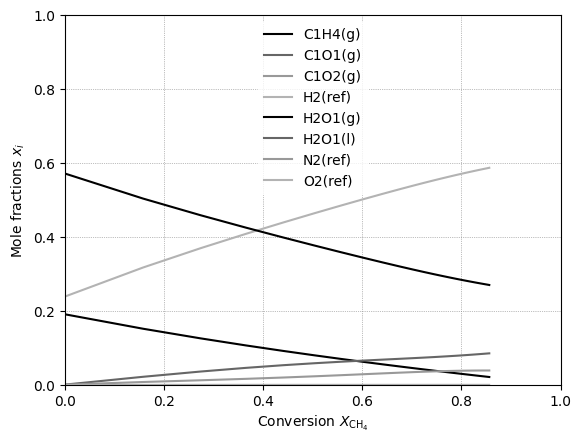

In [49]:
from phdtools.plots.smr import plot_molefraction_vs_conversion

fig = plot_molefraction_vs_conversion(
    DataID(DataType.FIGURE, Chapter.UNUSED, 9).get_path(fail_exists=False)
    / f"{FILE_DATE}_steam_reforming_kinetic_mole_fractions.csv"
)

## Equilibrium conversion from CEP
[back](#Table-of-contents)

see [White, Johnson and Dantzig (1958)](#References)

Define methane-conversion 
$$
X_\ce{CH4} = \frac{F_{\ce{CH4},0} - F_{\ce{CH4}}}{F_{\ce{CH4},0}} \tag{2}
$$
and partial fractional hydrogen-yield 
$$
\newcommand{\dd}{\mathrm{d}}
\varphi = \frac{\dd F_\ce{H2}}{-\dd F_\ce{CH4}} = \frac{r_\ce{H2}}{- r_\ce{CH4}}. \tag{3}
$$

Note 
$$
\begin{aligned}
    F_{\ce{CH4}} &= F_{\ce{CH4},0} \left( 1 - X_\ce{CH4} \right) \\
    \dd F_{\ce{CH4}} &= - F_{\ce{CH4},0} \, \dd X_\ce{CH4}
\end{aligned}
$$

In [50]:
import sqlite3
import pandas as pd

In [51]:
from phdtools.models.xu_froment_1989 import getEqMolarFlowOut, getEqConversion

In [52]:
pressureBar = 10

molarFlowRateIn = 0 * np.ones(len(Compound), dtype=np.float64)
molarFlowRateIn[Compound["C1H4(g)"].value] = 10
molarFlowRateIn[Compound["H2O1(g)"].value] = (
    3 * molarFlowRateIn[Compound["C1H4(g)"].value]
)
molarFlowRateIn[Compound["H2(ref)"].value] = (
    1.25 * molarFlowRateIn[Compound["C1H4(g)"].value]
)

In [53]:
molarFlowRateOut = getEqMolarFlowOut(molarFlowRateIn, pressureBar)
molarFlowRateOut.tail()

COMPOUND,C1H4(g),C1O1(g),C1O2(g),H2(ref),H2O1(g),H2O1(l),N2(ref),O2(ref)
T(K),,,,,,,,
1560.0,0.001564,8.688270,1.310166,43.805476,18.691397,0.0,0.0,0.0
1570.0,0.001398,8.703655,1.294946,43.790752,18.706452,0.0,0.0,0.0
1580.0,0.001252,8.718693,1.280055,43.776299,18.721197,0.0,0.0,0.0
1590.0,0.001123,8.733394,1.265483,43.762115,18.735639,0.0,0.0,0.0
1600.0,0.001008,8.747770,1.251222,43.748197,18.749786,0.0,0.0,0.0


In [54]:
eqConversion = (
    1 - molarFlowRateOut["C1H4(g)"] / molarFlowRateIn[Compound["C1H4(g)"].value]
)
eqYield = molarFlowRateOut["H2(ref)"] / (
    molarFlowRateIn[Compound["C1H4(g)"].value] - molarFlowRateOut["C1H4(g)"]
)

eqConversion.head()

T(K)
600.0    0.000015
610.0    0.000026
620.0    0.000047
630.0    0.000082
640.0    0.000141
Name: C1H4(g), dtype: float64

In [55]:
dataConversion = []
dataProduction = []
dataYield = []

for pressureBar in [5, 10, 20]:
    molarFlowRateOut = getEqMolarFlowOut(molarFlowRateIn, pressureBar)
    dataConversion.append(
        (
            1 - molarFlowRateOut["C1H4(g)"] / molarFlowRateIn[Compound["C1H4(g)"].value]
        ).rename(pressureBar)
    )
    dataProduction.append(
        (
            (molarFlowRateOut["H2(ref)"] - molarFlowRateIn[Compound["H2(ref)"].value])
            / molarFlowRateIn[Compound["C1H4(g)"].value]
        ).rename(pressureBar)
    )
    dataYield.append(
        (
            molarFlowRateOut["H2(ref)"]
            / (molarFlowRateIn[Compound["C1H4(g)"].value] - molarFlowRateOut["C1H4(g)"])
        ).rename(pressureBar)
    )

eqConversion = pd.concat(dataConversion, axis=1)
eqProduction = pd.concat(dataProduction, axis=1)
eqYield = pd.concat(dataYield, axis=1)

In [56]:
pressureBar = 10
steamToCarbonMolar = (
    molarFlowRateIn[Compound["H2O1(g)"].value]
    / molarFlowRateIn[Compound["C1H4(g)"].value]
)
hydrogenToCarbonMolar = (
    molarFlowRateIn[Compound["H2(ref)"].value]
    / molarFlowRateIn[Compound["C1H4(g)"].value]
)

data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 10)


@auto_create_path
def save_cep_equilibrium_conversion(path):

    description = (
        "Equilibrium conversion X_CH4 determined via direct Gibbs free energy minimization,\n"
        "see White, Johnson and Dantzig (1958).\n"
        "Values for the standard (molar) Gibbs free energy were computed as outlined in \n"
        "White, Johnson and Dantzig (1958) and  Gordon and Mcbride (1994, p. 19) using \n"
        "property data from Allison (2013), interpolating linearly between temperature values.\n"
        "\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n"
        'White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures", \n'
        "The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.\n"
        "Gordon, S. and Mcbride, B.J. (1994) Computer program for calculation of complex chemical equilibrium \n"
        "compositions and applications. Part 1: Analysis. Available at: https://ntrs.nasa.gov/citations/19950013764.\n"
    )

    fname1 = path / f"results_{TODAY}_eq_conversion_pressure_temperature.csv"
    with open(fname1, "w") as f:
        write_metadata(f, description="")
        eqConversion[pressureBar].to_csv(f)

    fname2 = path / f"results_{TODAY}_eq_production_pressure_temperature.csv"
    eqProduction[pressureBar].to_csv(fname2)


save_cep_equilibrium_conversion(
    data_id,
    doc=r"Equilibrium conversion determined via direct Gibbs free energy minimization; see \textcite{White.1958a}",
    overwrite=overwrite,
)

In [57]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 10).get_path(fail_exists=False)}

results_260407_eq_conversion_pressure_temperature.csv
results_260407_eq_production_pressure_temperature.csv


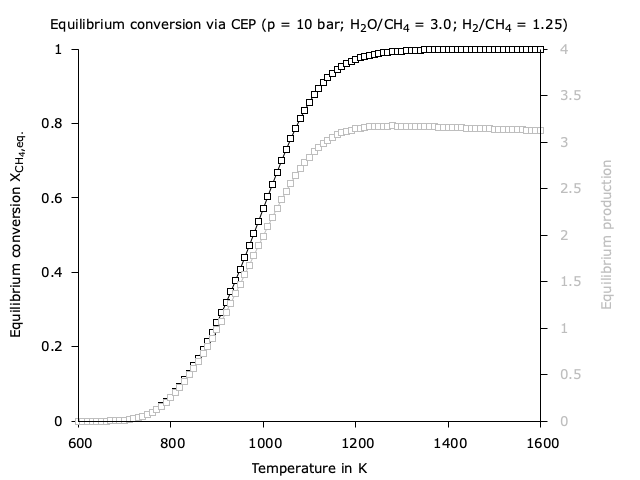

In [58]:
fname1 = DataID(DataType.FIGURE, Chapter.UNUSED, 10).get_path(fail_exists=False) / f"results_{FILE_DATE}_eq_conversion_pressure_temperature.csv"
fname2 = DataID(DataType.FIGURE, Chapter.UNUSED, 10).get_path(fail_exists=False) / f"results_{FILE_DATE}_eq_production_pressure_temperature.csv"

!gnuplot -e "\
    TITLE = 'Equilibrium conversion via CEP (p = {pressureBar} bar; H_2O/CH_4 = {steamToCarbonMolar}; H_2/CH_4 = {hydrogenToCarbonMolar})'; \
    conversion = '{fname1}'; \
    production = '{fname2}'; \
    call 'plot_240830_eq_conversion.gnu';\
"
del fname1
del fname2
Image("plots/plot_240830_eq_conversion.png")

## Equilibrium conversion from equilibrium constants
[back](#Table-of-contents)

In [59]:
from phdtools.models.xu_froment_1989 import get_equilibriumConversion, STST_PRESSURE_BAR
from scipy.optimize import newton

In [60]:
pressureBar = STST_PRESSURE_BAR
temperatureRange = np.linspace(600, 1600)
eqConversion = np.zeros(len(temperatureRange))
eqConversion[:] = np.nan

molarFlowRateIn = 0 * np.ones(len(Compound), dtype=np.float64)
molarFlowRateIn[Compound["C1H4(g)"].value] = 10
molarFlowRateIn[Compound["H2O1(g)"].value] = (
    3 * molarFlowRateIn[Compound["C1H4(g)"].value]
)
molarFlowRateIn[Compound["H2(ref)"].value] = (
    1.25 * molarFlowRateIn[Compound["C1H4(g)"].value]
)

for num, temperatureKelvin in enumerate(temperatureRange):
    eqConversion[num] = get_equilibriumConversion(
        molarFlowRateIn, temperatureKelvin, pressureBar, params, maxiter=2000
    )[0]

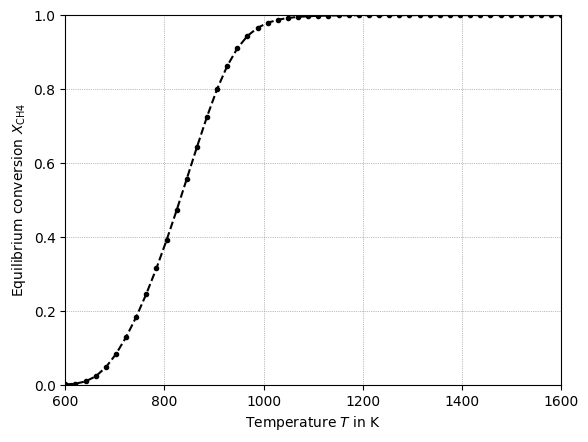

In [61]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.gca()

ax.plot(temperatureRange, eqConversion, ".--")

ax.set_xlabel(r"Temperature $T$ in K")
ax.set_ylabel(r"Equilibrium conversion $X_\mathrm{CH4}$")

ax.set_xlim(600, 1600)
ax.set_ylim(0, 1)
ax.grid(True)

## References
[back](#Table-of-contents)

1. Xu, J. and Froment, G.F. (1989) "Methane steam reforming, methanation and water-gas shift: I. Intrinsic kinetics", AIChE Journal, 35(1), pp. 88–96. Available at: https://doi.org/10.1002/aic.690350109.
2. Atkins, P.W., Paula, J. and Keeler, J. (2023) Atkins’ physical chemistry. Twelfth edition. New York NY: Oxford University Press.
3. White, W.B., Johnson, S.M. and Dantzig, G.B. (1958) "Chemical Equilibrium in Complex Mixtures,' The Journal of Chemical Physics, 28(5), pp. 751–755. Available at: https://doi.org/10.1063/1.1744264.